# Creating Pseudo-Reactions

> ### In this tutorial we will cover:
> - how we can use the `Reaction` class to define linkages without identifying the participating atoms directly

BuildAMol lives on the idea of connecting two molecules by establishing a bond between two atoms and removing (at least) to others in exchange. This allows us to create aribtrary structures irrespective of chemical constraints. 

Creating a `Linkage` is usually not difficult but requires some manual intervention, e.g. looking at the topology and identifying the right atom ids and residues. Functionalities such as functional groups, constrained atom searching, or automated downstream atom deletion provide some support to at least partially automate the process of identifying the right atoms to use when defining a linkage. However, they usually are either relatively constrained in their applicability (e.g. functional groups) or still require some additional boilerplate code to ultimately assemble finished molecules. 

The `Reaction` class provides a highlevel hub for exactly such boilerplate code to define linkages and connect molecules together. The input for the class are similar to that of a `Linkage` except that instead of providing individual atoms we can provide `function` that will be applied to dynamically obtain the right atoms from molecules when applying the reaction. Therefore Reactions are more powerful versions of the classic `Linkage`.

> The `Reaction` class is part of the core BuildAMol library as of version `1.2.11`. We can therefore directly use it as `bam.Reaction` after importing.

Let's check out how we can use it!

## Example 1 - Benzene + EtOH 

To start simple let's have ethanol perform an addition on a benzene ring. 
Our reaction mechanism should have the Oxygen perform attack an aromatic Carbon (with standard hydrogen-deletion). Remember, this is still BuildAMol so chemical reasoning is still not relevant when defining a "Reaction"! 

In [1]:
from warnings import filterwarnings
filterwarnings("ignore", category=DeprecationWarning)

import buildamol as bam
bam.load_small_molecules()

# start with getting the compounds
bnz = bam.get_compound("benzene")
etoh = bam.get_compound("ethanol")[0]

/opt/anaconda3/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Now we can define the Reaction we want to perform. To do so we need to define (at least) two functions:
1. A function to obtain `atom1` (i.e. the _target_ atom) that takes a `Molecule` as _only_ argument
2. A function to obtain `atom2` (i.e. the _source_ atom) that takes a `Molecule` as _only_ argument
3. (optional) A function to obtain the atoms to `delete_in_target` that takes at least a `Atom` as argument (will receive `atom1`) and can optionally receive the `Molecule` as second argument.
3. (optional) A function to obtain the atoms to `delete_in_source` that follows the same rules...

Once we have at least 1 and 2, we can set up our reaction. For our purposes the reaction could look like this:

In [2]:
reaction = bam.Reaction(
    atom1 = lambda mol: mol.get_atoms("C", by="element").pop(), # get any carbon (since all are aromatic in benzene)
    atom2 = lambda mol: mol.get_atoms("O", by="element").pop(), # get any oxygen (since ethanol only has one)
)

We don't need to define deletion atoms since Hydrogen-deletion is fine for now. To apply the reaction we can either _call_ the reaction with molecules or use the `apply` method.

/opt/anaconda3/lib/python3.12/site-packages/buildamol/utils/visual.py:164: DeprecationWarning: The `highlight_color` argument is deprecated and will be removed in future versions. Please specify a color when calling `highlight_atoms` or `highlight_bonds` instead.
  aux.deprecation_warning(
/opt/anaconda3/lib/python3.12/site-packages/buildamol/utils/visual.py:168: DeprecationWarning: The `linewidth` argument is deprecated and will be removed in future versions. Please specify a linewidth when calling the `draw` method instead.
  aux.deprecation_warning(


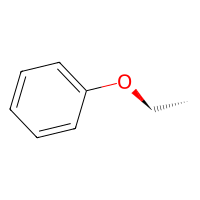

In [3]:

out = reaction(bnz, etoh)

# or
# out = reaction.apply(bnz, etoh)

out.draw2d().draw(height=200, width=200)

We can now actually reuse the same reaction to connect other molecules as well, as long as the atom functions are applicable to them.

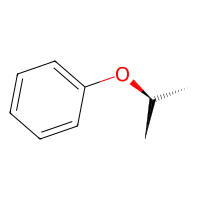

In [4]:
# get another alcohol
isopropanol = bam.molecule("isopropanol")
out2 = reaction(bnz, isopropanol)

out2.draw2d().draw(height=200, width=200)

## Example 2 - Extended Leaving Group

To make things a little more complex let's try making two functions now, one for adding and one for removing a tosylate group. 

In [5]:
tso = bam.molecule("Tosylate").add_hydrogens() # to make the SO3 group have an OH instead of O-
tso.rename_residue(1, "TSO")

phenol = bam.hydroxylate(bnz, 1) # first make phenol from benzene

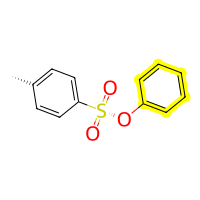

In [6]:
from buildamol.structural import constraints_v2 as constraints

add_tosylate = bam.Reaction(
    # in the target molecule we want to connect to some hydroxyl oxygen
    atom1 = lambda mol: mol.get_atoms("O", by="element", filter=constraints.has_neighbor_hist({"H": 1, "C": 1})).pop(),
    # in the tosylate (source) we want to connect to the Sulfur
    atom2 = lambda mol: mol.get_atoms("S", by="element").pop(),
    # we then want to get rid of the OH from the TsO 
    delete_in_source = lambda atom: atom.get_neighbors(filter=lambda a: a.element == "O" and len(a.get_hydrogens()) > 0).pop(),
)

# now we can use this to add tosylate groups
out3 = add_tosylate(phenol, tso)
out3.draw2d().highlight_residues(1, color="yellow").draw(height=200, width=200)

And now that we have a tosylated EtOH we can define a function to remove the tosylate again when having another reactant perform a nucleophilic attack on the **C**-O-TsO. This will involve a little more code for the functions we need to define but bear with and hopefully it will be clear how the setup works!

In [7]:
# in the target molecule we want to connect to some carbon 
# with an oxygen neighbor that neighbors a tosylate group
def get_attackable_carbons(mol):
    tso_sulfurs = mol.get_atoms("S", by="element", filter=lambda a: a.parent.name == "TSO")
    carbons_at_distance_2 = set()
    for sulfur in tso_sulfurs:
        neighbors = sulfur.get_neighbors(n=2, mode="at", filter=lambda a: a.element == "C" and a.parent.name != "TSO")
        carbons_at_distance_2.update(neighbors)
    return list(carbons_at_distance_2)

# for each attacked carbon we want to remove the tosylate group
# with automatic downstream deletion it is enough to identify the right oxygen
def get_tosylate_atoms(carbon):
    oxygen = carbon.get_neighbors(
        filter=lambda a: a.element == "O" and any(n.parent.name == "TSO" for n in a.get_neighbors())
    )
    if len(oxygen) == 0:
        raise ValueError("No tosylate oxygen found")
    return oxygen.pop()

# now we still need some mechanism for the attacking molecule
# to keep things simple on this side let's simply use an amine that performs a nucleophilic attack
def get_amine_nitrogen(mol):
    return mol.get_atoms("N", by="element", filter=constraints.has_neighbor_hist({"C": 1, "H": 2})).pop()


# with all of this we can now define the reaction
remove_tosylate = bam.Reaction(
    atom1 = get_attackable_carbons,
    atom2 = get_amine_nitrogen,
    delete_in_target = get_tosylate_atoms,
)

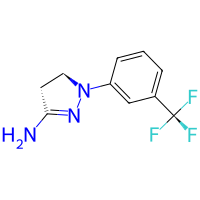

In [8]:
# let's get some primary amine from pubchem
amine = bam.molecule("BW-755C")

amine.draw2d().draw(height=200, width=200)

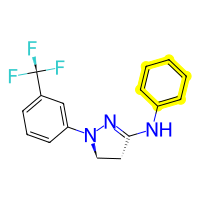

In [9]:
# and let it replace the tosylate group
out4 = remove_tosylate(out3, amine)
out4.draw2d().highlight_residues(1, color="yellow").draw(height=200, width=200)

This may look like a lot more effort than simply going and defining `Linkages` directly and if we are only going to modify molecules on a case-to-case basis then defining entire reactions is probably not worth the time. However, if your workflow involves repeadetly performing the same operations you will likely appreciate the power of the Reaction class.

Just to prove the concept that our function also works on other molecules let's also play with a second set of molecules:

/opt/anaconda3/lib/python3.12/site-packages/buildamol/utils/visual.py:164: DeprecationWarning: The `highlight_color` argument is deprecated and will be removed in future versions. Please specify a color when calling `highlight_atoms` or `highlight_bonds` instead.
  aux.deprecation_warning(
/opt/anaconda3/lib/python3.12/site-packages/buildamol/utils/visual.py:168: DeprecationWarning: The `linewidth` argument is deprecated and will be removed in future versions. Please specify a linewidth when calling the `draw` method instead.
  aux.deprecation_warning(
/opt/anaconda3/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(-0.5, 199.5, 199.5, -0.5)

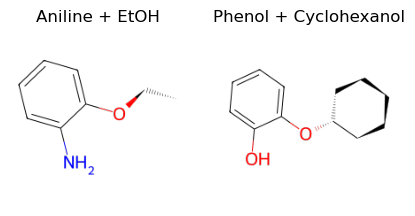

In [10]:
A = bam.molecule("aniline")
B = bam.molecule("cyclohexanol")

outA = reaction(A, etoh)
outB = reaction(phenol, B)


import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 4))
ax1.imshow(outA.draw2d().draw(ax=ax1, height=200, width=200))
ax2.imshow(outB.draw2d().draw(ax=ax2, height=200, width=200))
ax1.set_title("Aniline + EtOH")
ax2.set_title("Phenol + Cyclohexanol")
ax1.axis("off")
ax2.axis("off")

Let us also tosylate the cyclohexanol and _outB_.

(-0.5, 299.5, 299.5, -0.5)

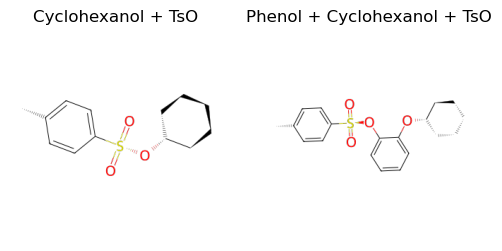

In [11]:
tso_B = add_tosylate(B, tso)
tso_outB = add_tosylate(outB, tso)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 9))

v_B = tso_B.draw2d().draw(height=300, width=300)
v_outB = tso_outB.draw2d().draw(height=300, width=300)
ax1.imshow(v_B)
ax2.imshow(v_outB)

ax1.set_title("Cyclohexanol + TsO")
ax2.set_title("Phenol + Cyclohexanol + TsO")
ax1.axis("off")
ax2.axis("off")

And finally use _outA_ to remove the tosylate group again.

(-0.5, 299.5, 299.5, -0.5)

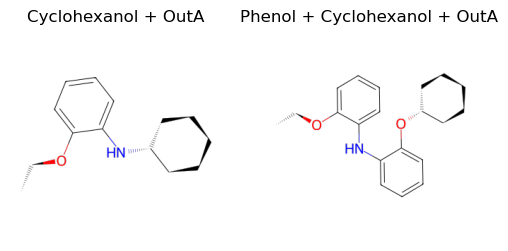

In [12]:
final_B = remove_tosylate(tso_B, outA)
final_outB = remove_tosylate(tso_outB, outA)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 9))

v_B = final_B.draw2d().draw(height=300, width=300)
v_outB = final_outB.draw2d().draw(height=300, width=300)

ax1.imshow(v_B)
ax2.imshow(v_outB)
ax1.set_title("Cyclohexanol + OutA")
ax2.set_title("Phenol + Cyclohexanol + OutA")
ax1.axis("off")
ax2.axis("off")

## Multiple target sites

So far we have had reactions perform a single operation each time. However, we can also have a reaction perform multiple additions at multiple target sites simultaneously. To do so, we simply have to let the `atom1` function return an iterable of multiple `Atom` objects (e.g. a tuple, list, or set). 

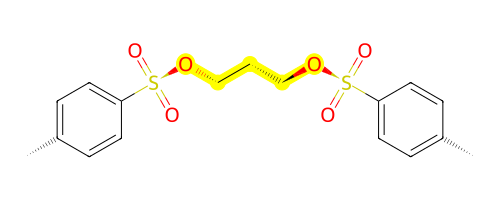

In [ ]:
# actually, our add tosylate function already checks for all possible hydroxyl groups
# but then simply pops the first one it finds
# to change this we can either redefine the Reaction using the `set` method or we create a copy
# of it with a modified atom1 function using the `with_reactivity` method. 

# let's get a new reaction that checks all hydroxyl groups
multiple_site_add_tosylate = add_tosylate.with_reactivity(
    # this time we don't pop at the end so we get all possible hydroxyl oxygens
    atom1 = lambda mol: mol.get_atoms("O", by="element", filter=constraints.has_neighbor_hist({"H": 1, "C": 1})),
)

C = bam.read_smiles("OCCCO")

# and add tosylate groups
outC = multiple_site_add_tosylate(C, tso)

outC.draw2d().highlight_residues(1, color="yellow").draw(height=200, width=500)

And there we have it, two tosylate groups added together! 

And with that we have reached the end of this tutorial on the `Reaction` class! As we have seen we can define reusable and flexible reaction mechanisms by simply defining functions that find the right atoms to participate in defining a linkage. 

Thanks and good luck with your research project using BuildAMol!